# Prepare Modeling Data

This notebook loads the scaled fraud dataset, splits it into train and test sets, applies SMOTENC only to the training split, and saves model-ready artifacts for downstream training.

## 1. Imports & Setup

Set up the notebook environment, file paths, and modeling constants.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split

# Keep notebook output readable in each cell.
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

BASE_DIR = Path(r'c:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system')
INPUT_PATH = BASE_DIR / 'dataset' / 'processed' / 'credit_card_fraud_scaled.csv'
OUTPUT_DIR = BASE_DIR / 'artifacts'
TARGET_COL = 'is_fraud'
ID_COL = 'transaction_id'
CONTINUOUS_COLS = ['amount', 'transaction_hour', 'velocity_last_24h', 'cardholder_age']

print('Imports and setup complete.')

Imports and setup complete.


In [ ]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(f'Input file not found: {INPUT_PATH}. Run handle_scaling.ipynb first.')

# Load the scaled dataset from disk.
df = pd.read_csv(INPUT_PATH)
print(f'Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]:,} columns')

if ID_COL in df.columns:
    df = df.drop(columns=[ID_COL])
    print(f'Dropped {ID_COL}')

if TARGET_COL not in df.columns:
    raise ValueError(f'Missing target column: {TARGET_COL}')

# Quick preview to confirm the columns look correct.
df.head()

Loaded dataset: 10,000 rows x 13 columns


,amount,transaction_hour,foreign_transaction,location_mismatch,velocity_last_24h,cardholder_age,is_fraud,device_trust_score_binned,merchant_category_Clothing,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,-0.5608,1.5033,0,0,0.7066,-0.2316,0,2,0,1,0,0,0
1,2.4460,-1.2414,1,0,-0.7103,1.3707,0,3,0,0,0,0,1
2,0.4690,0.7810,0,0,-0.7103,1.1704,0,1,0,0,0,1,0
3,-0.0217,-1.0969,0,1,0.7066,-0.6322,0,2,0,0,0,1,0
4,-0.9250,0.4921,0,0,-1.4188,0.0355,0,3,0,0,1,0,0


## 2. Load Scaled Dataset

Read the scaled input file and remove the identifier column before modeling.

In [ ]:
# Separate features and label before resampling.
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Target distribution before split:')
print(y.value_counts().sort_index())
print(f'Train shape before SMOTENC: {X_train.shape[0]:,} rows x {X_train.shape[1]:,} columns')
print(f'Test shape: {X_test.shape[0]:,} rows x {X_test.shape[1]:,} columns')

Target distribution before split:
is_fraud
0    9849
1     151
Name: count, dtype: int64
Train shape before SMOTENC: 8,000 rows x 12 columns
Test shape: 2,000 rows x 12 columns


## 3. Train/Test Split

Separate features from the target and create a stratified split.

In [ ]:
# Everything except the continuous columns is treated as categorical for SMOTENC.
categorical_cols = [col for col in X_train.columns if col not in CONTINUOUS_COLS]
categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]

if not categorical_features:
    raise ValueError('No categorical columns were detected for SMOTENC.')

print(f'Continuous columns: {CONTINUOUS_COLS}')
print(f'Categorical columns: {categorical_cols}')

Continuous columns: ['amount', 'transaction_hour', 'velocity_last_24h', 'cardholder_age']
Categorical columns: ['foreign_transaction', 'location_mismatch', 'device_trust_score_binned', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']


## 4. Identify Categorical Features

Detect the categorical columns that SMOTENC should treat as discrete.

In [ ]:
# Resample the training data only.
smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train, y_train)

print('Target distribution after SMOTENC:')
print(pd.Series(y_train_resampled).value_counts().sort_index())

Target distribution after SMOTENC:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


## 5. Apply SMOTENC

Oversample only the training split to avoid leakage into the test set.

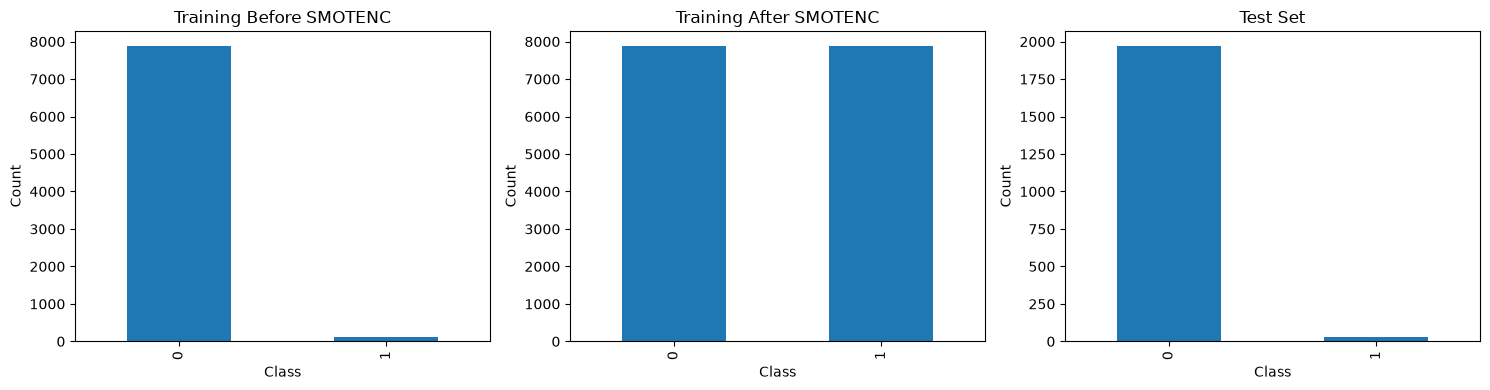

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pd.Series(y_train).value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Training Before SMOTENC')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

pd.Series(y_train_resampled).value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Training After SMOTENC')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

pd.Series(y_test).value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Test Set')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')

plt.tight_layout()

## 6. Visualize Class Balance

Compare the class distribution before and after resampling.

In [ ]:
# Restore column names before writing the final tables.
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
y_train_resampled = pd.Series(y_train_resampled, name=TARGET_COL)
train_resampled = pd.concat([X_train_resampled, y_train_resampled], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

print(train_resampled.head())

   amount  transaction_hour  foreign_transaction  location_mismatch  \
0 -0.8546           -0.8080                    0                  1   
1 -0.7458           -0.8080                    0                  0   
2 -0.8325           -1.6748                    0                  0   
3  1.5478            1.6478                    0                  0   
4 -0.9952           -1.6748                    0                  0   

   velocity_last_24h  cardholder_age  device_trust_score_binned  \
0            -0.0018          0.5028                          3   
1            -0.0018         -1.7004                          1   
2            -0.0018         -1.2330                          1   
3            -0.7103         -0.6322                          3   
4            -0.7103         -1.0327                          3   

   merchant_category_Clothing  merchant_category_Electronics  \
0                           0                              0   
1                           0             

## 7. Build Output Tables

Convert the resampled arrays back into DataFrames for saving.

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save the model-ready artifacts in the root artifacts folder.
#train_resampled.to_csv(OUTPUT_DIR / 'credit_card_fraud_train_resampled.csv', index=False)
#test_set.to_csv(OUTPUT_DIR / 'credit_card_fraud_test.csv', index=False)
np.savez_compressed(OUTPUT_DIR / 'credit_card_fraud_X_train.npz', X_train=X_train_resampled.to_numpy())
np.savez_compressed(OUTPUT_DIR / 'credit_card_fraud_y_train.npz', y_train=y_train_resampled.to_numpy())
np.savez_compressed(OUTPUT_DIR / 'credit_card_fraud_X_test.npz', X_test=X_test.to_numpy())
np.savez_compressed(OUTPUT_DIR / 'credit_card_fraud_y_test.npz', y_test=y_test.to_numpy())

print(f'Saved train/test artifacts to: {OUTPUT_DIR}')

Saved train/test artifacts to: c:\Users\2021ICTS28\Desktop\end-to-end-credit-card-fraud-detection-system\artifacts


## 8. Save Artifacts

Write the final train/test files to the root-level artifacts folder.

In [21]:
print('Model data preparation complete.')
print(f'Resampled train shape: {train_resampled.shape[0]:,} rows x {train_resampled.shape[1]:,} columns')
print(f'Test shape: {test_set.shape[0]:,} rows x {test_set.shape[1]:,} columns')

Model data preparation complete.
Resampled train shape: 15,758 rows x 13 columns
Test shape: 2,000 rows x 13 columns


## 9. Summary

Confirm the notebook completed successfully and report the final shapes.